In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout

# 1. Load Data
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["target"] = housing.target

# 2. Funzione Outliers
def remove_outliers_zscore(data, columns, threshold=3):
    df_clean = data.copy()
    z_scores = np.abs(stats.zscore(df_clean[columns]))
    filtered_entries = (z_scores < threshold).all(axis=1)
    return df_clean[filtered_entries]

df_zscore = remove_outliers_zscore(df, ['MedInc', 'AveRooms', 'AveOccup'])
print(f"Righe rimosse con Z-Score: {len(df) - len(df_zscore)}")



Righe rimosse con Z-Score: 482


In [14]:
# 3. Preparazione X e y
X = df_zscore[housing.feature_names].values
y = df_zscore["target"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. STANDARDIZZAZIONE (Obbligatoria per Keras)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [15]:
# 5. Modello Keras per Regressione
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1) # ATTENZIONE: 1 neurone e NESSUNA attivazione (regressione lineare)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

from keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=7, 
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# 6. Addestramento
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/60


C:\Users\elisabetta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


404/404 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.9281 - mae: 0.6939 - val_loss: 0.4763 - val_mae: 0.4766 - learning_rate: 0.0010
Epoch 2/60
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5250 - mae: 0.5276 - val_loss: 0.4568 - val_mae: 0.4618 - learning_rate: 0.0010
Epoch 3/60
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4533 - mae: 0.4889 - val_loss: 0.4013 - val_mae: 0.4362 - learning_rate: 0.0010
Epoch 4/60
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4299 - mae: 0.4740 - val_loss: 0.4520 - val_mae: 0.4603 - learning_rate: 0.0010
Epoch 5/60
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4148 - mae: 0.4639 - val_loss: 0.3914 - val_mae: 0.4289 - learning_rate: 0.0010
Epoch 6/60
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3996 - mae: 0.4536 - val_loss: 0.3585 - val_mae: 0.4166 - learning_rate: 0.0010
Epoch 7/60
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3864 - mae: 0.4456 - val_loss: 0.3863 - val_mae: 0.4230 - learning_rate: 0.0010
Epoch 8/60
404/40

In [16]:
# 7. Valutazione e Grafici
y_pred = model.predict(X_test_scaled).flatten()
mse = mean_squared_error(y_test, y_pred)
print(f"MSE finale con Keras: {mse:.4f}")

# Calcoliamo il MAE
mae = mean_absolute_error(y_test, y_pred)

print(f"MAE finale con Keras: {mae:.4f}")

# Calcoliamo l'errore percentuale medio
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"La percentuale media di errore è: {mape:.2f}%")

126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MSE finale con Keras: 0.3452
MAE finale con Keras: 0.4150
La percentuale media di errore è: 23.42%


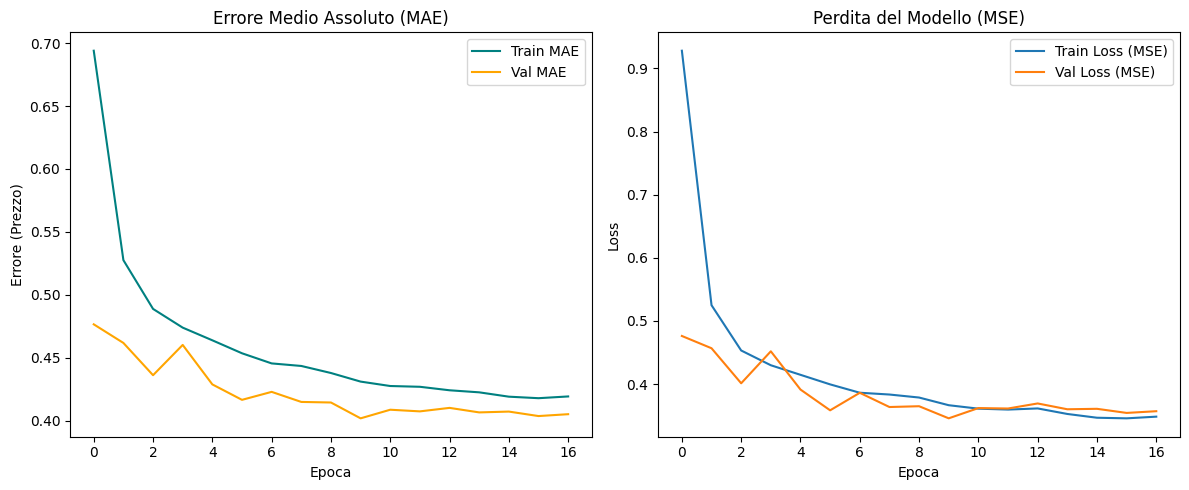

In [17]:
import matplotlib.pyplot as plt

# Creiamo una figura con due grafici (Sottoplot)
plt.figure(figsize=(12, 5))

# 1. Grafico dell'Errore Medio Assoluto (MAE)
# In regressione il MAE ci dice di quanti "dollari" (in media) stiamo sbagliando
plt.subplot(1, 2, 1)
plt.plot(history.history['mae'], label='Train MAE', color='teal')
plt.plot(history.history['val_mae'], label='Val MAE', color='orange')
plt.title('Errore Medio Assoluto (MAE)')
plt.xlabel('Epoca')
plt.ylabel('Errore (Prezzo)')
plt.legend()

# 2. Grafico della Perdita (Loss / MSE)
# Questo grafico mostra come la rete minimizza l'errore quadratico
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Perdita del Modello (MSE)')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

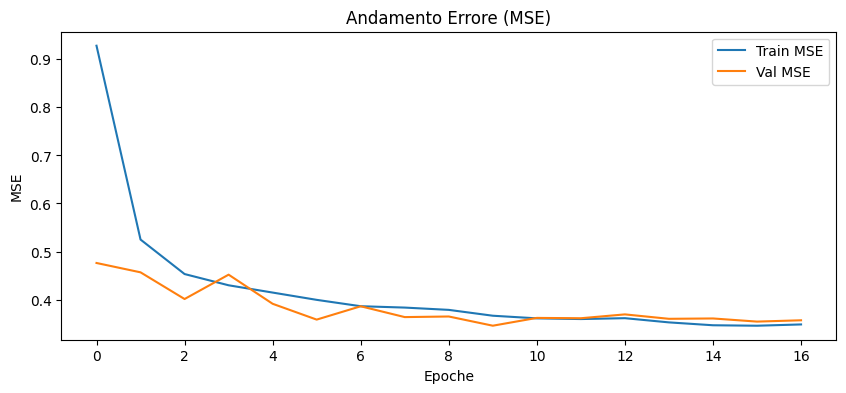

In [18]:
# Grafico Loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train MSE')
plt.plot(history.history['val_loss'], label='Val MSE')
plt.title('Andamento Errore (MSE)')
plt.xlabel('Epoche')
plt.ylabel('MSE')
plt.legend()
plt.show()